In [24]:
import re
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

BASE = "https://www.federalreserve.gov"
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36"
}

response = requests.get(BASE + "/monetarypolicy/fomccalendars.htm", headers=headers, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")

links = sorted({urljoin(BASE, a["href"]) for a in soup.find_all("a", href=True)
                if re.search(r"monetary2026\d{4}a\.htm", a["href"])})

print("status:", response.status_code)
print("statements found:", len(links))
for link in links:
    print(link)

status: 200
statements found: 6
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260318a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260429a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260617a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260729a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260916a.htm


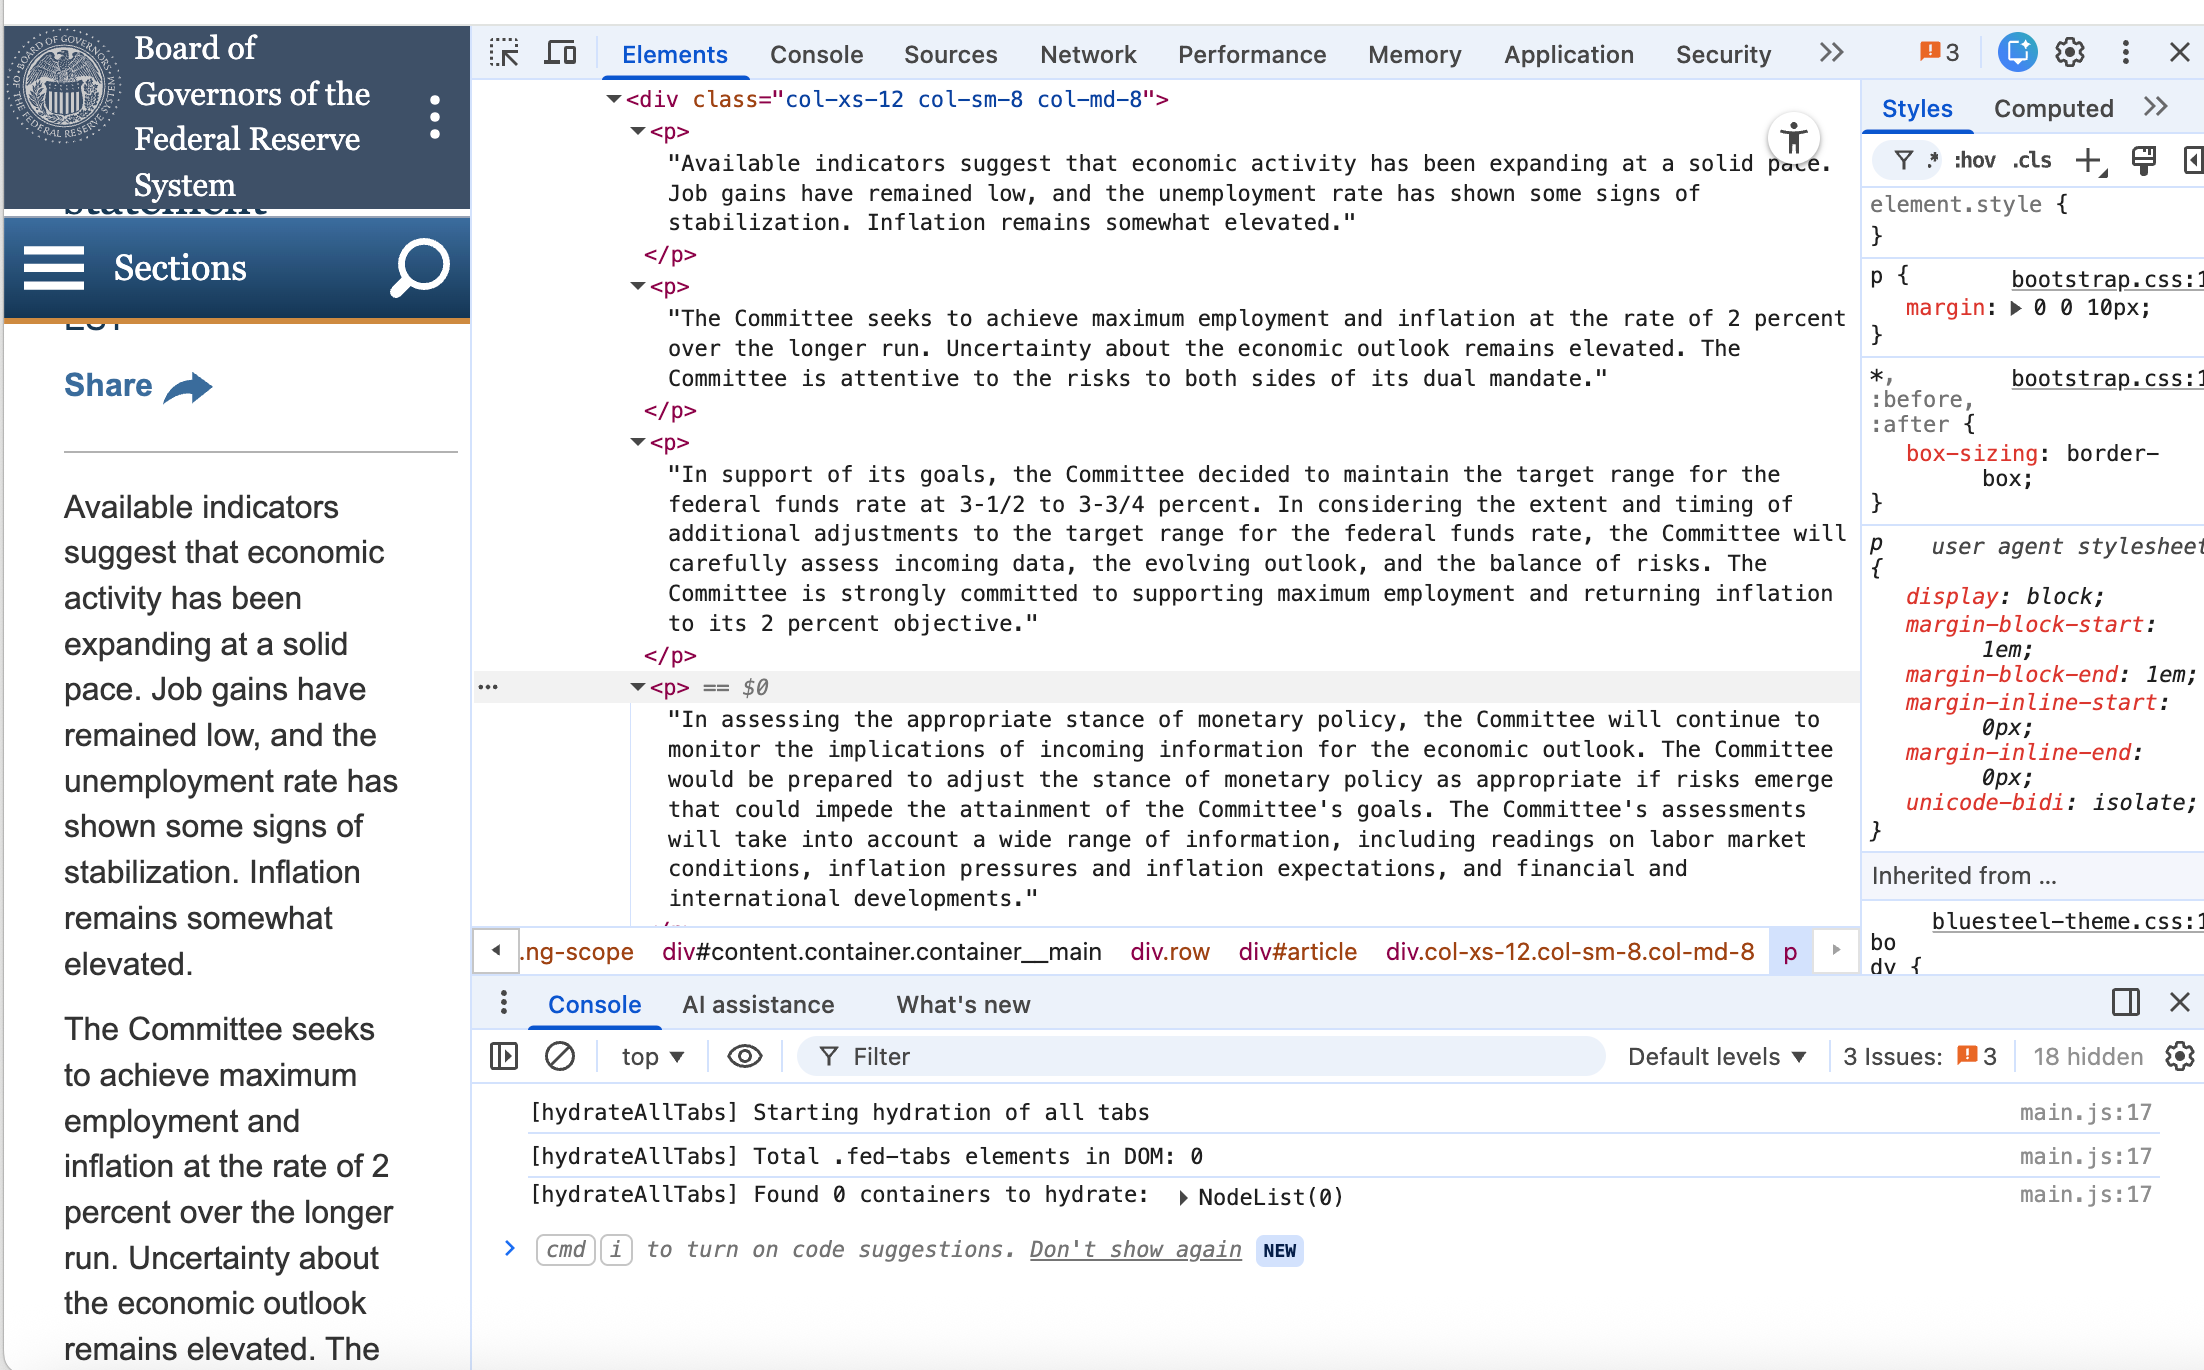

**Used "Inspect" to find where the statement text sits: inside <div id="article">**

In [25]:
import time
import pandas as pd

DASHES = str.maketrans({c: "-" for c in "\u2010\u2011\u2012\u2013\u2014"})

pages = {}
for link in links:
    r = requests.get(link, headers=headers, timeout=10)
    r.encoding = "utf-8"
    article = BeautifulSoup(r.text, "html.parser").find("div", id="article")
    pages[link] = [p.get_text(" ", strip=True).translate(DASHES) for p in article.find_all("p")]
    time.sleep(1)

print("statements fetched:", len(pages))

statements fetched: 6


In [26]:
vote_keywords = ["vote"]

vote_check = pd.DataFrame(
    {kw: [kw in " ".join(paras).lower() for paras in pages.values()] for kw in vote_keywords},
    index=[link[-13:-5] for link in pages],
)
vote_check

,vote
20260128,False
20260318,False
20260429,False
20260617,True
20260729,True
20260916,True


In [27]:
for link, paras in pages.items():
    print(link[-13:-5])
    for i, p in enumerate(paras):
        if re.search(r"\bvot", p, re.IGNORECASE):
            print(i, p)
    print()

20260128
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bowman; Lisa D. Cook; Beth M. Hammack; Philip N. Jefferson; Neel Kashkari; Lorie K. Logan; and Anna Paulson. Voting against this action were Stephen I. Miran and Christopher J. Waller, who preferred to lower the target range for the federal funds rate by 1/4 percentage point at this meeting.

20260318
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bowman; Lisa D. Cook; Beth M. Hammack; Philip N. Jefferson; Neel Kashkari; Lorie K. Logan; Anna Paulson; and Christopher J. Waller. Voting against this action was Stephen I. Miran, who preferred to lower the target range for the federal funds rate by 1/4 percentage point at this meeting.

20260429
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bo

In [28]:
import numpy as np

NAME = r"[A-Z][a-z]+ (?:[A-Z]\. )?[A-Z][a-z]+"

def get_votes(link, paras):
    vtext = " ".join(p for p in paras if re.search(r"\bvot", p, re.IGNORECASE))

    tally = re.search(r"by a (\d+)\s*-\s*(\d+) vote", vtext)
    for_part = re.search(r"Voting for .*? were (.+?)(?:Voting against|$)", vtext)
    against_part = re.search(r"Voting against .*? (?:were|was) (.+)", vtext)

    voters_for = []
    if for_part:
        clean = for_part.group(1).replace(", Vice Chair", "").replace(", Chair", "")
        voters_for = re.findall(NAME, clean)

    voters_against = []
    if against_part:
        clean = re.sub(r", who [^;]*", "", against_part.group(1))
        voters_against = re.findall(NAME, clean)

    if tally:
        ratio = f"{tally.group(1)}-{tally.group(2)}"
    elif voters_for:
        ratio = f"{len(voters_for)}-{len(voters_against)}"
    else:
        ratio = np.nan

    return {
        "date": link[-13:-5],
        "vote_ratio": ratio,
        "voters_against": ", ".join(voters_against) or np.nan,
    }

votes = pd.DataFrame([get_votes(link, paras) for link, paras in pages.items()])
votes

,date,vote_ratio,voters_against
0,20260128,10-2,"Stephen I. Miran, Christopher J. Waller"
1,20260318,11-1,Stephen I. Miran
2,20260429,8-4,"Stephen I. Miran, Beth M. Hammack, Neel Kashka..."
3,20260617,12-0,NaN
4,20260729,9-3,"Beth M. Hammack, Neel Kashkari, Lorie K. Logan"
5,20260916,12-0,NaN


In [29]:
votes.to_csv("fomc_2026_votes.csv", index=False, encoding="utf-8-sig")

## Summary

- **Approach:** Got the 6 statement links for 2026 from the FOMC calendar page. Used Chrome DevTools (Inspect) to see where the text (`div#article`). Then I pulled it from each statement. 
- **Challenge:** My first try crashed. Their format changed. To see every way 'vote' is written, I searched all paragraphs for "vot-".
- **Result:** Get vote ratio and dissenters for all 6 meetings, and saved as csv.